# Periodogram reliability test

Notebook is split into three practical blocks:

1. generate synthetic seven-day DORIS-like data with known periodicities and realistic noise,
2. detect significant periodicities with FFT,
3. detect significant periodicities with Lomb-Scargle.

Each method computes the full periodogram, displays it as a table, estimates a 95% false-alarm threshold, marks significant peaks, subtracts the detected periodic signal, and compares scatter before and after subtraction.

## 1. Data generation

## Imports

In [1]:
# --- Standard library ---
import sys
from pathlib import Path

# --- Third-party packages ---
try:
    import numpy as np
except ImportError as e:
    raise RuntimeError("Missing dependency: 'numpy'. Install it with:\n  pip install numpy") from e

try:
    import pandas as pd
    pd.set_option("display.float_format", "{:.5f}".format)
except ImportError as e:
    raise RuntimeError("Missing dependency: 'pandas'. Install it with:\n  pip install pandas") from e

try:
    import matplotlib.pyplot as plt
except ImportError as e:
    raise RuntimeError("Missing dependency: 'matplotlib'. Install it with:\n  pip install matplotlib") from e

try:
    from IPython.display import display
except ImportError:
    display = print

# --- doris package ---
_src = Path("../../src").resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

try:
    from doris.analysis.spectral import (
        compute_periodogram,
        estimate_periodogram_threshold,
        find_significant_peaks,
    )
except ImportError as e:
    raise RuntimeError(
        "Missing doris modules. Make sure the project src path is on PYTHONPATH "
        "or run the notebook from the expected directory."
    ) from e


## Parameters

In [2]:
# --- Time axis ---
START_DATE = "2016-01-06 12:00:00"
YEARS = 10
SAMPLING_DAYS = 7
N_SAMPLES = int(YEARS * 365.25 / SAMPLING_DAYS)

# --- Known periodic components ---
PERIOD_05Y = 0.5
PERIOD_1Y = 1.0
PERIOD_200D = 200 / 365.25

AMP_05Y = 5.0
AMP_1Y = 10.0
AMP_200D = 7.0

known_periods = np.array([PERIOD_05Y, PERIOD_1Y, PERIOD_200D])
known_names = ["semiannual", "annual", "200 days"]
known_amplitudes = np.array([AMP_05Y, AMP_1Y, AMP_200D])

known_table = pd.DataFrame({
    "name": known_names,
    "period_year": known_periods,
    "period_days": known_periods * 365.25,
    "amplitude_mm": known_amplitudes,
})

# --- Periodogram search range ---
MIN_PERIOD = 0.15
MAX_PERIOD = 3.0
N_LOMB_FREQUENCIES = 6000

# --- Significance settings ---
FALSE_ALARM_LEVEL = 0.95
N_FALSE_ALARM = 200
TOP_N_PEAKS = 12
PERIOD_MATCH_TOLERANCE = 0.08

# --- Figure output ---
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "LaTeX").exists():
    PROJECT_ROOT = Path("../..").resolve()

FIG_DIR = PROJECT_ROOT / "LaTeX" / "images" / "test" / "periodicities"
FIG_DIR.mkdir(parents=True, exist_ok=True)

known_table

,name,period_year,period_days,amplitude_mm
0,semiannual,0.50000,182.62500,5.00000
1,annual,1.00000,365.25000,10.00000
2,200 days,0.54757,200.00000,7.00000


In [3]:
from doris.output.tables import Col, save_latex_table

# --- Výstupní adresář pro tabulky ---
TABLES_DIR = PROJECT_ROOT / "LaTeX" / "tables" / "test" / "periodicities"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# --- Exportní tabulka s českými názvy ---
known_table_export = known_table[["period_days", "amplitude_mm"]].copy()
known_table_export.insert(0, "name_cs", ["půlroční", "roční", "200 dní"])

_ = save_latex_table(
    known_table_export,
    TABLES_DIR / "known_periodicities.tex",
    cols=[
        Col("name_cs",      "Název",          None),
        Col("period_days",  "Perioda [dny]",  3),
        Col("amplitude_mm", "Amplituda [mm]", 3),
    ],
    caption="Parametry generovaných periodických složek.",
    label="tab:known_periodicities",
    print_preview=True,
)

\begin{table}[H]
\centering
\caption{Parametry generovaných periodických složek.}
\label{tab:known_periodicities}
\begin{tabular}{lrr}
\toprule
Název & Perioda [dny] & Amplituda [mm] \\
\midrule
půlroční & 182.625 & 5.000 \\
roční & 365.250 & 10.000 \\
200 dní & 200.000 & 7.000 \\
\bottomrule
\end{tabular}
\end{table}



## Time axis and periodic components

In [4]:
def decimal_year(dates):
    dates = pd.DatetimeIndex(pd.to_datetime(dates))
    year_start = pd.to_datetime(dates.year.astype(str) + "-01-01")
    next_year_start = pd.to_datetime((dates.year + 1).astype(str) + "-01-01")
    return dates.year + (dates - year_start) / (next_year_start - year_start)


dates = pd.date_range(START_DATE, periods=N_SAMPLES, freq=f"{SAMPLING_DAYS}D")
year = decimal_year(dates).to_numpy(dtype=float)
t = year - year[0]

signal_05y = AMP_05Y * np.sin(2 * np.pi * t / PERIOD_05Y)
signal_1y = AMP_1Y * np.sin(2 * np.pi * t / PERIOD_1Y)
signal_200d = AMP_200D * np.sin(2 * np.pi * t / PERIOD_200D)

y_periodic = signal_05y + signal_1y + signal_200d

periodic_df = pd.DataFrame({
    "Date": dates,
    "year": year,
    "t_year": t,
    "signal_05y": signal_05y,
    "signal_1y": signal_1y,
    "signal_200d": signal_200d,
    "y_periodic": y_periodic,
})

periodic_df.head()

,Date,year,t_year,signal_05y,signal_1y,signal_200d,y_periodic
0,2016-01-06 12:00:00,2016.01503,0.00000,0.00000,0.00000,0.00000,0.00000
1,2016-01-13 12:00:00,2016.03415,0.01913,1.19017,1.19881,1.52392,3.91290
2,2016-01-20 12:00:00,2016.05328,0.03825,2.31191,2.38033,2.97475,7.66699
3,2016-01-27 12:00:00,2016.07240,0.05738,3.30076,3.52752,4.28287,11.11115
4,2016-02-03 12:00:00,2016.09153,0.07650,4.09986,4.62383,5.38554,14.10923


## Clean periodic signal

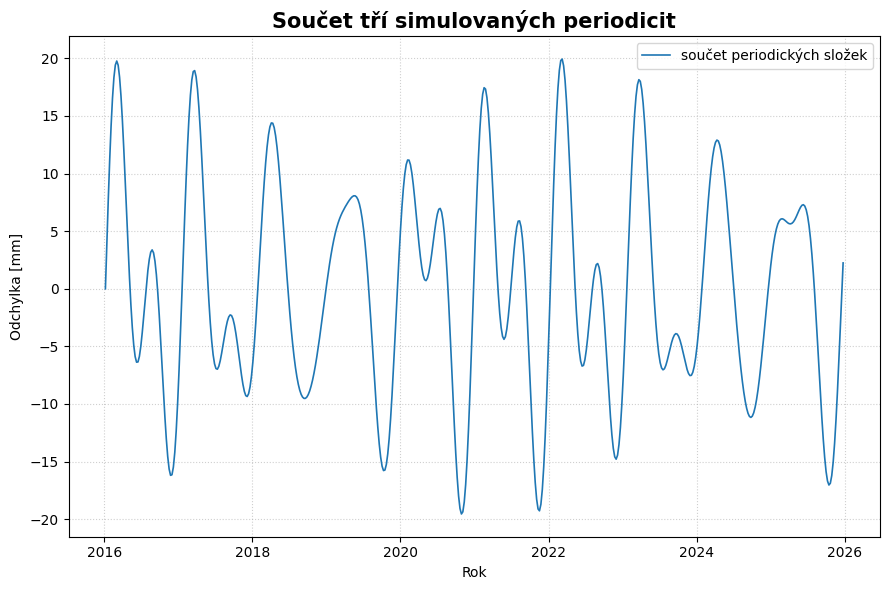

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(periodic_df["year"], periodic_df["y_periodic"], color="tab:blue", linewidth=1.2, label="součet periodických složek")

ax.set_xlabel("Rok")
ax.set_ylabel("Odchylka [mm]")
ax.set_title("Součet tří simulovaných periodicit", fontsize=15, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "periodic_signal.pdf", bbox_inches="tight")
plt.show()

## Realistic noise model

In [6]:
# --- Šum: gaussovský + odlehlá měření ---

np.random.seed(42)  # fixní seed

n = len(t)

sigma = 5        # gaussovský šum (mm)
p_odl = 0.01     # podíl odlehlých měření (1 %)
sigma_odl = 20   # velikost odlehlých měření (mm)

gaussian_noise = np.random.normal(0, sigma, n)

odlehla_mereni = (np.random.rand(n) < p_odl) * np.random.normal(0, sigma_odl, n)

y_noise = gaussian_noise + odlehla_mereni

## Noise-only test data

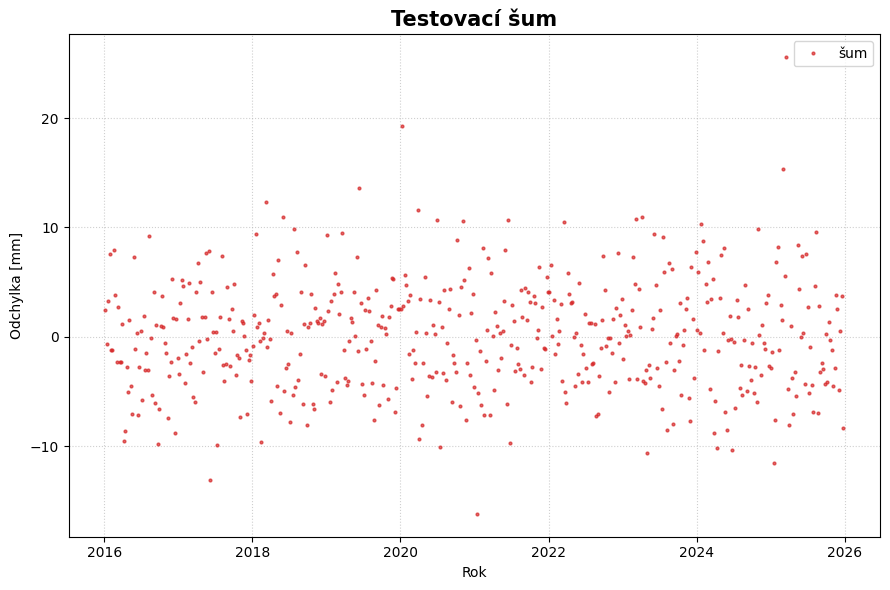

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(year, y_noise, ".", ms=4, alpha=0.70, color="tab:red", label="šum")

ax.set_xlabel("Rok")
ax.set_ylabel("Odchylka [mm]")
ax.set_title("Testovací šum", fontsize=15, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "noise_only.pdf", bbox_inches="tight")
plt.show()

## Final test data: periodic signal plus noise

In [8]:
test_df = pd.DataFrame({
    "Date": dates,
    "year": year,
    "t_year": t,
    "signal_05y": signal_05y,
    "signal_1y": signal_1y,
    "signal_200d": signal_200d,
    "y_clean": y_periodic,
    "noise": y_noise,
})
test_df["y"] = test_df["y_clean"] + test_df["noise"]

print("Seven-day samples:", len(test_df))
test_df.head()

Seven-day samples: 521


,Date,year,t_year,signal_05y,signal_1y,signal_200d,y_clean,noise,y
0,2016-01-06 12:00:00,2016.01503,0.00000,0.00000,0.00000,0.00000,0.00000,2.48357,2.48357
1,2016-01-13 12:00:00,2016.03415,0.01913,1.19017,1.19881,1.52392,3.91290,-0.69132,3.22158
2,2016-01-20 12:00:00,2016.05328,0.03825,2.31191,2.38033,2.97475,7.66699,3.23844,10.90544
3,2016-01-27 12:00:00,2016.07240,0.05738,3.30076,3.52752,4.28287,11.11115,7.61515,18.72630
4,2016-02-03 12:00:00,2016.09153,0.07650,4.09986,4.62383,5.38554,14.10923,-1.17077,12.93846


## Final test data plot

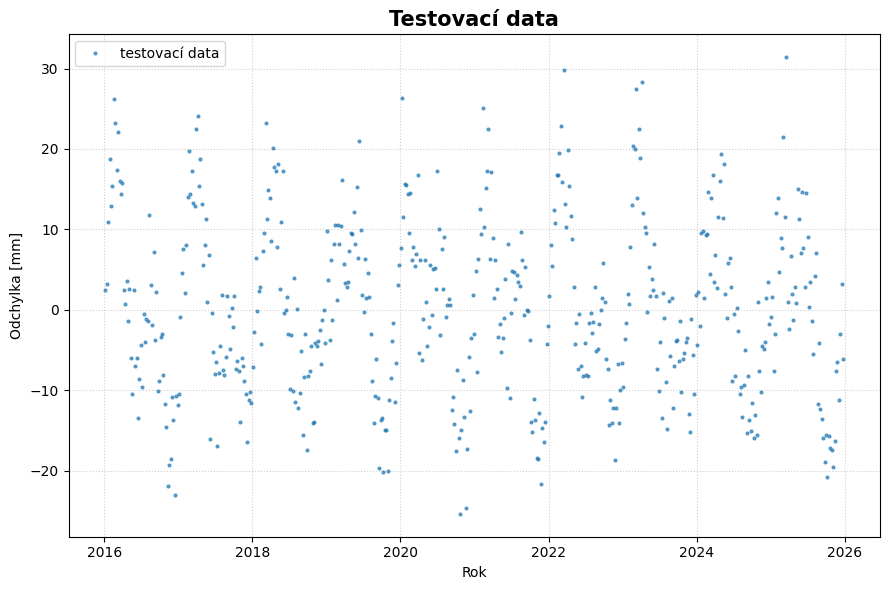

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(test_df["year"], test_df["y"], ".", ms=4, alpha=0.65, label="testovací data")

ax.set_xlabel("Rok")
ax.set_ylabel("Odchylka [mm]")
ax.set_title("Testovací data", fontsize=15, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "test_data.pdf", bbox_inches="tight")
plt.show()

## 2. FFT analysis

## FFT: complete periodogram table

In [10]:
fft_pg = compute_periodogram(
    test_df,
    method="fft",
    time_col="t_year",
    value_cols="y",
    min_period=MIN_PERIOD,
    max_period=MAX_PERIOD,
)

fft_periodogram = fft_pg.copy()
fft_periodogram["period_days"] = fft_periodogram["period"] * 365.25

display(fft_periodogram)

,frequency,period,amplitude,power,phase_rad,period_days
0,6.60543,0.15139,0.29095,0.08465,2.77910,55.29542
1,6.50535,0.15372,0.75321,0.56732,-0.73953,56.14612
2,6.40526,0.15612,0.20079,0.04032,2.41240,57.02341
3,6.30518,0.15860,0.23451,0.05500,2.41841,57.92854
4,6.20510,0.16116,0.74694,0.55792,1.25513,58.86287
...,...,...,...,...,...,...
58,0.80066,1.24897,0.14674,0.02153,2.42659,456.18724
59,0.70058,1.42740,0.21030,0.04423,0.24238,521.35685
60,0.60049,1.66530,0.40912,0.16738,2.33397,608.24966
61,0.50041,1.99836,0.58059,0.33709,0.98838,729.89959


## FFT: 95% threshold and significant peaks

In [11]:
fft_threshold_95 = estimate_periodogram_threshold(
    test_df,
    method="fft",
    time_col="t_year",
    value_cols="y",
    value_col="amplitude",
    false_alarm_level=FALSE_ALARM_LEVEL,
    n_permutations=N_FALSE_ALARM,
    min_period=MIN_PERIOD,
    max_period=MAX_PERIOD,
    random_state=2026,
)

fft_significant_peaks = find_significant_peaks(
    fft_pg,
    threshold=fft_threshold_95,
    value_col="amplitude",
    n_peaks=TOP_N_PEAKS,
)

print(f"FFT 95% false-alarm threshold: {fft_threshold_95:.3f} mm")
display(fft_significant_peaks[["period", "period_days", "amplitude", "power"]])

FFT 95% false-alarm threshold: 2.502 mm


,period,period_days,amplitude,power
0,0.99918,364.94979,10.67294,113.91158
1,0.55510,202.74989,6.36743,40.54417
2,0.49959,182.47490,4.67885,21.89164


In [12]:
# --- FFT: export tabulky detekovanch period ---
_ = save_latex_table(
    fft_significant_peaks,
    TABLES_DIR / "fft_significant_peaks.tex",
    cols=[
        Col("period",      "Perioda [roky]", 5),
        Col("period_days", "Perioda [dny]",  3),
        Col("amplitude",   "Amplituda [mm]", 3),
    ],
    caption="Periodické složky detekované metodou FFT.",
    label="tab:fft_significant_peaks",
    font_size=r"\small",
    print_preview=True,
)

\begin{table}[H]
\centering
\small
\caption{Periodické složky detekované metodou FFT.}
\label{tab:fft_significant_peaks}
\begin{tabular}{rrr}
\toprule
Perioda [roky] & Perioda [dny] & Amplituda [mm] \\
\midrule
0.99918 & 364.950 & 10.673 \\
0.55510 & 202.750 & 6.367 \\
0.49959 & 182.475 & 4.679 \\
\bottomrule
\end{tabular}
\end{table}



## FFT: periodogram with significant peaks

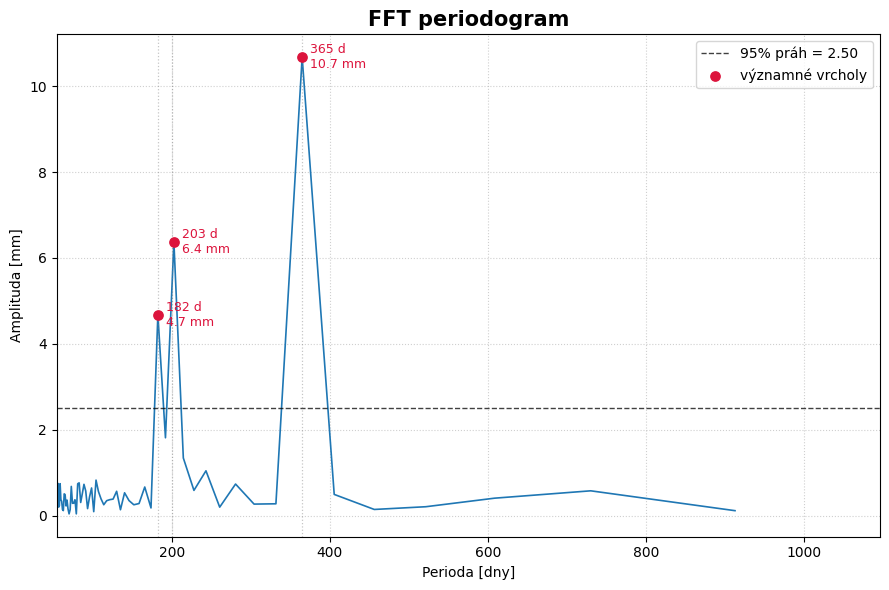

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(fft_periodogram["period_days"], fft_periodogram["amplitude"], color="tab:blue", linewidth=1.2)
ax.axhline(fft_threshold_95, color="black", linestyle="--", linewidth=1.0, alpha=0.75, label=f"95% práh = {fft_threshold_95:.2f}")

if not fft_significant_peaks.empty:
    ax.scatter(
        fft_significant_peaks["period_days"],
        fft_significant_peaks["amplitude"],
        color="crimson",
        s=45,
        zorder=3,
        label="významné vrcholy",
    )

    for peak in fft_significant_peaks.itertuples(index=False):
        ax.annotate(
            f"{peak.period_days:.0f} d\n{peak.amplitude:.1f} mm",
            xy=(peak.period_days, peak.amplitude),
            xytext=(6, -8),
            textcoords="offset points",
            fontsize=9,
            color="crimson",
        )

ax.axvline(PERIOD_05Y * 365.25, color="gray", linestyle=":", alpha=0.45, linewidth=0.9)
ax.axvline(PERIOD_1Y * 365.25, color="gray", linestyle=":", alpha=0.45, linewidth=0.9)
ax.axvline(PERIOD_200D * 365.25, color="gray", linestyle=":", alpha=0.45, linewidth=0.9)

ax.set_xlim(MIN_PERIOD * 365.25, MAX_PERIOD * 365.25)
ax.set_xlabel("Perioda [dny]")
ax.set_ylabel("Amplituda [mm]")
ax.set_title("FFT periodogram", fontsize=15, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "fft_periodogram.pdf", bbox_inches="tight")
plt.show()

## FFT: subtract detected periodicities

In [14]:
fft_detected_periods = fft_significant_peaks["period"].to_numpy()

t_fft = test_df["t_year"].to_numpy()
y_fft = test_df["y"].to_numpy()

# Fit sin and cos terms for all detected periods.
fft_columns = [np.ones_like(t_fft)]
for period in fft_detected_periods:
    omega = 2 * np.pi / period
    fft_columns.append(np.sin(omega * t_fft))
    fft_columns.append(np.cos(omega * t_fft))

fft_design = np.column_stack(fft_columns)
fft_coef, *_ = np.linalg.lstsq(fft_design, y_fft, rcond=None)

fft_periodic_signal = fft_design[:, 1:] @ fft_coef[1:]
fft_residual = y_fft - fft_periodic_signal

fft_fit_rows = []
for i, period in enumerate(fft_detected_periods):
    sin_coef = fft_coef[1 + 2 * i]
    cos_coef = fft_coef[2 + 2 * i]
    fft_fit_rows.append({
        "period": period,
        "period_days": period * 365.25,
        "amplitude": np.hypot(sin_coef, cos_coef),
    })
fft_fit_table = pd.DataFrame(fft_fit_rows)

fft_match_rows = []
for known_name, known_period, known_amplitude in zip(known_names, known_periods, known_amplitudes):
    errors = np.abs(fft_significant_peaks["period"].to_numpy() - known_period) / known_period
    best_idx = int(np.argmin(errors))
    best = fft_significant_peaks.iloc[best_idx]
    fft_match_rows.append({
        "known_name": known_name,
        "known_period_days": known_period * 365.25,
        "known_amplitude_mm": known_amplitude,
        "found_period_days": best["period_days"],
        "found_amplitude_mm": best["amplitude"],
        "relative_error_pct": 100 * errors[best_idx],
        "matched": errors[best_idx] <= PERIOD_MATCH_TOLERANCE,
    })
fft_known_vs_found = pd.DataFrame(fft_match_rows)

fft_scatter = pd.DataFrame([
    {"series": "before subtraction", "std_mm": np.std(y_fft, ddof=1), "variance_mm2": np.var(y_fft, ddof=1)},
    {"series": "after subtraction", "std_mm": np.std(fft_residual, ddof=1), "variance_mm2": np.var(fft_residual, ddof=1)},
])

print("Generated periodicities:")
display(known_table[["name", "period_days", "amplitude_mm"]])

print("Detected FFT periodicities used for subtraction:")
display(fft_fit_table)

print("Known vs detected FFT periodicities:")
display(fft_known_vs_found)

print("Scatter before and after FFT subtraction:")
display(fft_scatter)

Generated periodicities:


,name,period_days,amplitude_mm
0,semiannual,182.62500,5.00000
1,annual,365.25000,10.00000
2,200 days,200.00000,7.00000


Detected FFT periodicities used for subtraction:


,period,period_days,amplitude
0,0.99918,364.94979,10.68395
1,0.55510,202.74989,6.32133
2,0.49959,182.47490,4.65156


Known vs detected FFT periodicities:


,known_name,known_period_days,known_amplitude_mm,found_period_days,found_amplitude_mm,relative_error_pct,matched
0,semiannual,182.62500,5.00000,182.47490,4.67885,0.08219,True
1,annual,365.25000,10.00000,364.94979,10.67294,0.08219,True
2,200 days,200.00000,7.00000,202.74989,6.36743,1.37494,True


Scatter before and after FFT subtraction:


,series,std_mm,variance_mm2
0,before subtraction,10.77675,116.13838
1,after subtraction,5.29418,28.02831


## FFT: data after subtraction

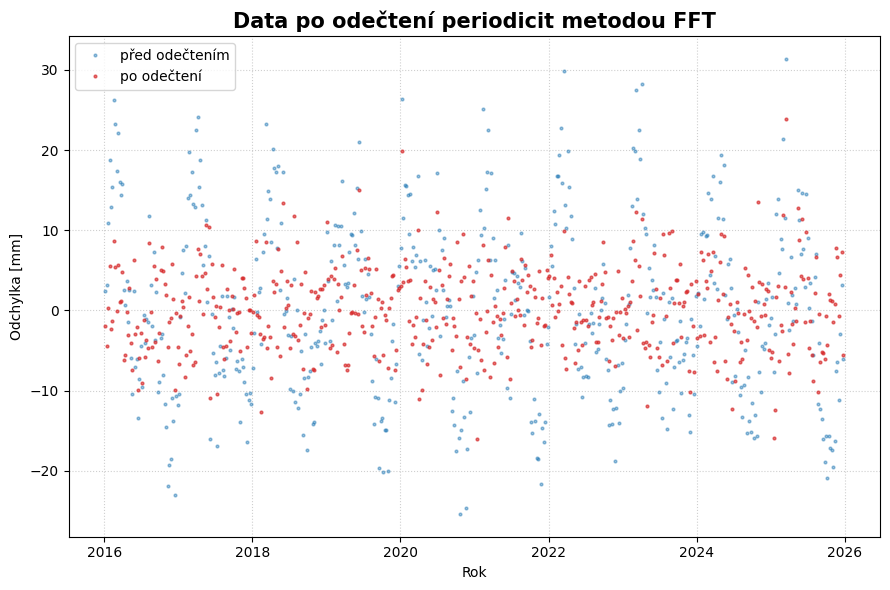

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(test_df["year"], test_df["y"], ".", ms=4, alpha=0.45, color="tab:blue", label="před odečtením")
ax.plot(test_df["year"], fft_residual, ".", ms=4, alpha=0.65, color="tab:red", label="po odečtení")

ax.set_xlabel("Rok")
ax.set_ylabel("Odchylka [mm]")
ax.set_title("Data po odečtení periodicit metodou FFT", fontsize=15, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "fft_residual.pdf", bbox_inches="tight")
plt.show()

## 3. Lomb-Scargle analysis

## Lomb-Scargle: complete periodogram table

In [16]:
lomb_pg = compute_periodogram(
    test_df,
    method="lomb_scargle",
    time_col="t_year",
    value_cols="y",
    min_period=MIN_PERIOD,
    max_period=MAX_PERIOD,
    n_frequencies=N_LOMB_FREQUENCIES,
)

lomb_periodogram = lomb_pg.copy()
lomb_periodogram["period_days"] = lomb_periodogram["period"] * 365.25

display(lomb_periodogram)

,frequency,period,amplitude,power,phase_rad,period_days
0,6.66667,0.15000,0.11075,0.00005,1.60993,54.78750
1,6.66561,0.15002,0.10942,0.00005,1.64819,54.79618
2,6.66456,0.15005,0.10817,0.00005,1.68844,54.80486
3,6.66350,0.15007,0.10701,0.00005,1.73070,54.81354
4,6.66244,0.15010,0.10594,0.00005,1.77502,54.82223
...,...,...,...,...,...,...
5995,0.33756,2.96247,1.02624,0.00439,1.94403,1082.04185
5996,0.33650,2.97176,1.01741,0.00430,1.97275,1085.43663
5997,0.33544,2.98112,1.00732,0.00421,2.00120,1088.85278
5998,0.33439,2.99053,0.99598,0.00411,2.02937,1092.29050


## Lomb-Scargle: 95% threshold and significant peaks

In [17]:
lomb_threshold_95 = estimate_periodogram_threshold(
    test_df,
    method="lomb_scargle",
    time_col="t_year",
    value_cols="y",
    value_col="amplitude",
    false_alarm_level=FALSE_ALARM_LEVEL,
    n_permutations=N_FALSE_ALARM,
    min_period=MIN_PERIOD,
    max_period=MAX_PERIOD,
    n_frequencies=N_LOMB_FREQUENCIES,
    random_state=2026,
)

lomb_significant_peaks = find_significant_peaks(
    lomb_pg,
    threshold=lomb_threshold_95,
    value_col="amplitude",
    n_peaks=TOP_N_PEAKS,
)

print(f"Lomb-Scargle 95% false-alarm threshold: {lomb_threshold_95:.3f} mm")
display(lomb_significant_peaks[["period", "period_days", "amplitude", "power"]])

Lomb-Scargle 95% false-alarm threshold: 2.691 mm


,period,period_days,amplitude,power
0,1.00156,365.81915,10.69254,0.49473
1,0.55015,200.94165,6.62922,0.18926
2,0.49599,181.16038,4.81152,0.09934
3,1.16689,426.20789,3.43875,0.05133


In [18]:
# --- Lomb-Scargle: export tabulky detekovanch period ---
_ = save_latex_table(
    lomb_significant_peaks,
    TABLES_DIR / "lomb_significant_peaks.tex",
    cols=[
        Col("period",      "Perioda [roky]", 5),
        Col("period_days", "Perioda [dny]",  3),
        Col("amplitude",   "Amplituda [mm]", 3),
    ],
    caption="Periodické složky detekované Lomb--Scargleovou metodou.",
    label="tab:lomb_significant_peaks",
    font_size=r"\small",
    print_preview=True,
)

\begin{table}[H]
\centering
\small
\caption{Periodické složky detekované Lomb--Scargleovou metodou.}
\label{tab:lomb_significant_peaks}
\begin{tabular}{rrr}
\toprule
Perioda [roky] & Perioda [dny] & Amplituda [mm] \\
\midrule
1.00156 & 365.819 & 10.693 \\
0.55015 & 200.942 & 6.629 \\
0.49599 & 181.160 & 4.812 \\
1.16689 & 426.208 & 3.439 \\
\bottomrule
\end{tabular}
\end{table}



## Lomb-Scargle: periodogram with significant peaks

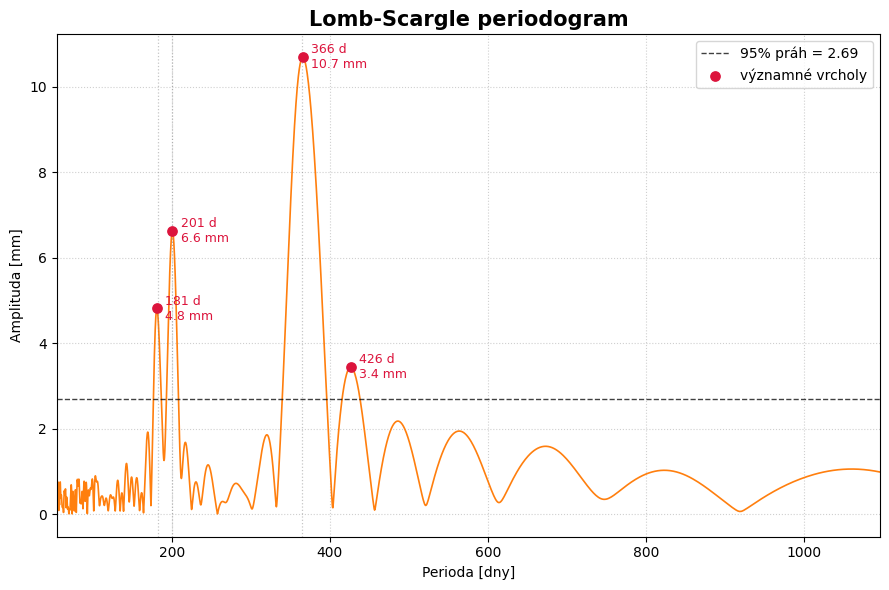

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(lomb_periodogram["period_days"], lomb_periodogram["amplitude"], color="tab:orange", linewidth=1.2)
ax.axhline(lomb_threshold_95, color="black", linestyle="--", linewidth=1.0, alpha=0.75, label=f"95% práh = {lomb_threshold_95:.2f}")

if not lomb_significant_peaks.empty:
    ax.scatter(
        lomb_significant_peaks["period_days"],
        lomb_significant_peaks["amplitude"],
        color="crimson",
        s=45,
        zorder=3,
        label="významné vrcholy",
    )

    for peak in lomb_significant_peaks.itertuples(index=False):
        ax.annotate(
            f"{peak.period_days:.0f} d\n{peak.amplitude:.1f} mm",
            xy=(peak.period_days, peak.amplitude),
            xytext=(6, -8),
            textcoords="offset points",
            fontsize=9,
            color="crimson",
        )

ax.axvline(PERIOD_05Y * 365.25, color="gray", linestyle=":", alpha=0.45, linewidth=0.9)
ax.axvline(PERIOD_1Y * 365.25, color="gray", linestyle=":", alpha=0.45, linewidth=0.9)
ax.axvline(PERIOD_200D * 365.25, color="gray", linestyle=":", alpha=0.45, linewidth=0.9)

ax.set_xlim(MIN_PERIOD * 365.25, MAX_PERIOD * 365.25)
ax.set_xlabel("Perioda [dny]")
ax.set_ylabel("Amplituda [mm]")
ax.set_title("Lomb-Scargle periodogram", fontsize=15, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "lomb_scargle_periodogram.pdf", bbox_inches="tight")
plt.show()

## Lomb-Scargle: subtract detected periodicities

In [20]:
lomb_detected_periods = lomb_significant_peaks["period"].to_numpy()

t_lomb = test_df["t_year"].to_numpy()
y_lomb = test_df["y"].to_numpy()

# Fit sin and cos terms for all detected periods.
lomb_columns = [np.ones_like(t_lomb)]
for period in lomb_detected_periods:
    omega = 2 * np.pi / period
    lomb_columns.append(np.sin(omega * t_lomb))
    lomb_columns.append(np.cos(omega * t_lomb))

lomb_design = np.column_stack(lomb_columns)
lomb_coef, *_ = np.linalg.lstsq(lomb_design, y_lomb, rcond=None)

lomb_periodic_signal = lomb_design[:, 1:] @ lomb_coef[1:]
lomb_residual = y_lomb - lomb_periodic_signal

lomb_fit_rows = []
for i, period in enumerate(lomb_detected_periods):
    sin_coef = lomb_coef[1 + 2 * i]
    cos_coef = lomb_coef[2 + 2 * i]
    lomb_fit_rows.append({
        "period": period,
        "period_days": period * 365.25,
        "amplitude": np.hypot(sin_coef, cos_coef),
    })
lomb_fit_table = pd.DataFrame(lomb_fit_rows)

lomb_match_rows = []
for known_name, known_period, known_amplitude in zip(known_names, known_periods, known_amplitudes):
    errors = np.abs(lomb_significant_peaks["period"].to_numpy() - known_period) / known_period
    best_idx = int(np.argmin(errors))
    best = lomb_significant_peaks.iloc[best_idx]
    lomb_match_rows.append({
        "known_name": known_name,
        "known_period_days": known_period * 365.25,
        "known_amplitude_mm": known_amplitude,
        "found_period_days": best["period_days"],
        "found_amplitude_mm": best["amplitude"],
        "relative_error_pct": 100 * errors[best_idx],
        "matched": errors[best_idx] <= PERIOD_MATCH_TOLERANCE,
    })
lomb_known_vs_found = pd.DataFrame(lomb_match_rows)

lomb_scatter = pd.DataFrame([
    {"series": "before subtraction", "std_mm": np.std(y_lomb, ddof=1), "variance_mm2": np.var(y_lomb, ddof=1)},
    {"series": "after subtraction", "std_mm": np.std(lomb_residual, ddof=1), "variance_mm2": np.var(lomb_residual, ddof=1)},
])

print("Generated periodicities:")
display(known_table[["name", "period_days", "amplitude_mm"]])

print("Detected Lomb-Scargle periodicities used for subtraction:")
display(lomb_fit_table)

print("Known vs detected Lomb-Scargle periodicities:")
display(lomb_known_vs_found)

print("Scatter before and after Lomb-Scargle subtraction:")
display(lomb_scatter)

Generated periodicities:


,name,period_days,amplitude_mm
0,semiannual,182.62500,5.00000
1,annual,365.25000,10.00000
2,200 days,200.00000,7.00000


Detected Lomb-Scargle periodicities used for subtraction:


,period,period_days,amplitude
0,1.00156,365.81915,10.40890
1,0.55015,200.94165,6.53016
2,0.49599,181.16038,4.74137
3,1.16689,426.20789,0.68185


Known vs detected Lomb-Scargle periodicities:


,known_name,known_period_days,known_amplitude_mm,found_period_days,found_amplitude_mm,relative_error_pct,matched
0,semiannual,182.62500,5.00000,181.16038,4.81152,0.80198,True
1,annual,365.25000,10.00000,365.81915,10.69254,0.15582,True
2,200 days,200.00000,7.00000,200.94165,6.62922,0.47083,True


Scatter before and after Lomb-Scargle subtraction:


,series,std_mm,variance_mm2
0,before subtraction,10.77675,116.13838
1,after subtraction,5.10483,26.05931


## Lomb-Scargle: data after subtraction

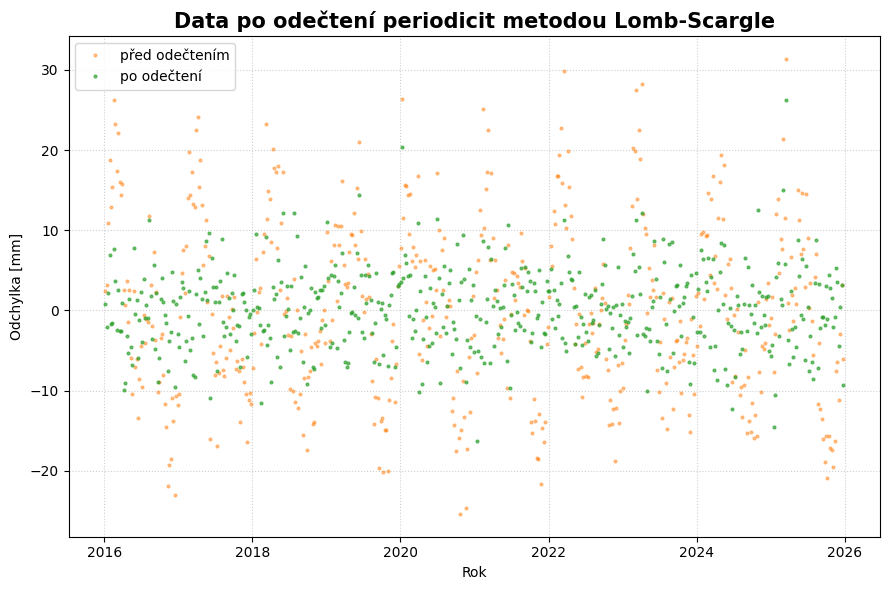

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(test_df["year"], test_df["y"], ".", ms=4, alpha=0.45, color="tab:orange", label="před odečtením")
ax.plot(test_df["year"], lomb_residual, ".", ms=4, alpha=0.65, color="tab:green", label="po odečtení")

ax.set_xlabel("Rok")
ax.set_ylabel("Odchylka [mm]")
ax.set_title("Data po odečtení periodicit metodou Lomb-Scargle", fontsize=15, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "lomb_scargle_residual.pdf", bbox_inches="tight")
plt.show()